In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [73]:
X, Y = 100,100
lattice = Lattice(X, Y, pbc_x=True)
N= X*Y

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1.5 * t /2
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=U, V_prime=None, V=None,
                F0_init=0.2)
                # F_init=[0.1, -0.1, 0.1j, -0.1j])

In [74]:
energies = np.linspace(-3,3,1000) 
dos_values = H.dos(energies, eta=0.01)/ N

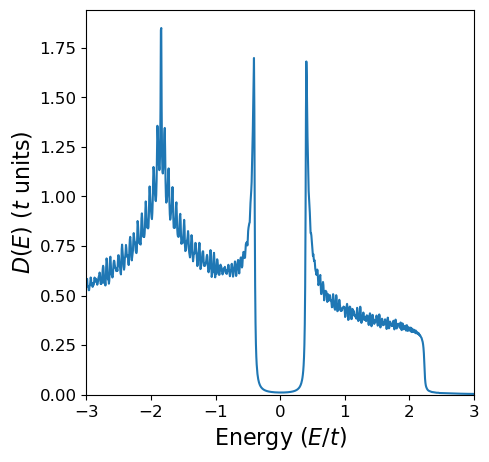

In [75]:
plt.figure(figsize=(5,5))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-3,3)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [76]:
X, Y = 100,100
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 2 * t / 2
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.2, -0.2, 0.2j, -0.2j])

energies = np.linspace(-3,3,1000) 
dos_values2 = H.dos(energies, eta=0.01) / N

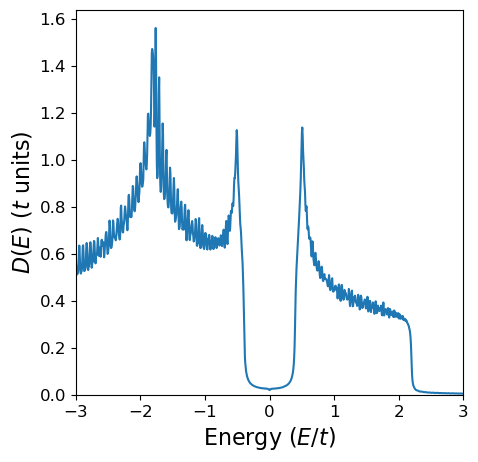

In [77]:
plt.figure(figsize=(5,5))
plt.plot(energies, dos_values2)
plt.ylim(0, None)
plt.xlim(-3,3)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [79]:
X, Y = 100,100
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 2 * t / 2
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.2, -0.2, 0.2, -0.2])

energies = np.linspace(-3,3,1000) 
dos_values3 = H.dos(energies, eta=0.01) / N

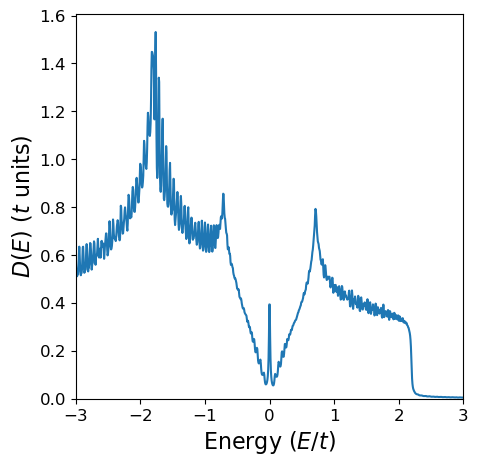

In [80]:
plt.figure(figsize=(5,5))
plt.plot(energies, dos_values3)
plt.ylim(0, None)
plt.xlim(-3,3)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [85]:
X, Y = 100,100
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 2 * t / 2
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.2, 0.2, -0.2, -0.2])

energies = np.linspace(-3,3,1000) 
dos_values4 = H.dos(energies, eta=0.01) / N

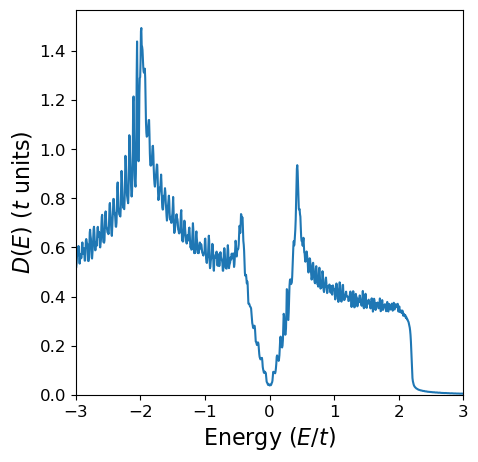

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(energies, dos_values4)
plt.ylim(0, None)
plt.xlim(-3,3)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [87]:
X, Y = 100,100
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 2 * t / 2
V_prime = V0 * np.ones(lattice.X)

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=V_prime, V=None,
                Fuu_init=[0.2, -0.2, 0.2j, -0.2j],
                Fdd_init=[0.2, -0.2, 0.2j, -0.2j])

energies = np.linspace(-3,3,1000) 
dos_values_uu1 = H.dos(energies, eta=0.01) / N

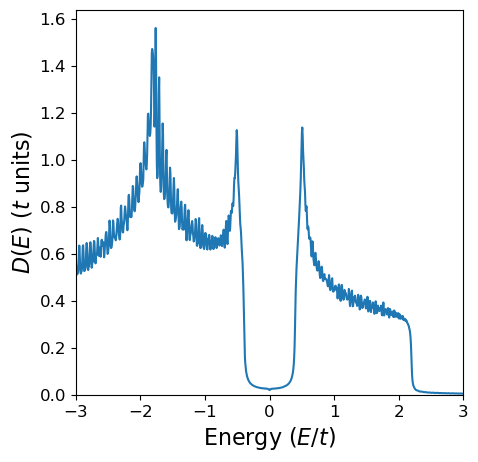

In [103]:
plt.figure(figsize=(5,5))
plt.plot(energies, dos_values_uu1)
plt.ylim(0, None)
plt.xlim(-3,3)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

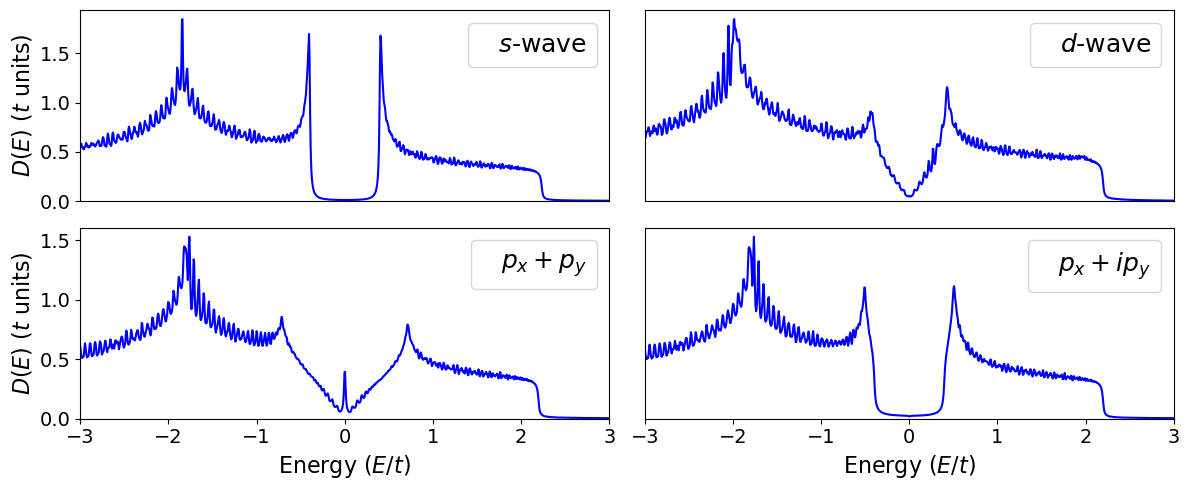

In [120]:
fig, axs = plt.subplots(2, 2, figsize=(12, 5))
axs[0][0].plot(energies, dos_values, color='blue', label=r'$s$-wave')
axs[0][0].set_ylim(0, None)
axs[0][0].set_xlim(-3,3)
axs[0][0].set_ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
axs[0][0].set_xticks([])
axs[0][0].tick_params(axis='y', labelsize=14)
axs[0][0].legend(fontsize=18, handlelength=0.)

axs[0][1].plot(energies, dos_values4, color='blue', label=r'$d$-wave')
axs[0][1].set_ylim(0, None)
axs[0][1].set_xlim(-3,3)
axs[0][1].set_xticks([])
axs[0][1].set_yticks([])
axs[0][1].tick_params(axis='y', labelsize=14)
axs[0][1].legend(fontsize=18, handlelength=0.)

axs[1][0].plot(energies, dos_values3, color='blue', label=r'$p_x+p_y$')
axs[1][0].set_ylim(0, None)
axs[1][0].set_xlim(-3,3)
axs[1][0].set_ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
axs[1][0].tick_params(axis='x', labelsize=14)
axs[1][0].tick_params(axis='y', labelsize=14)
axs[1][0].legend(fontsize=18, handlelength=0.)
axs[1][0].set_xlabel(r'Energy ($E/t$)', fontsize=16)

axs[1][1].plot(energies, dos_values2, color='blue', label=r'$p_x+ip_y$')
axs[1][1].set_ylim(0, None)
axs[1][1].set_xlim(-3,3)
axs[1][1].tick_params(axis='x', labelsize=14)
axs[1][1].tick_params(axis='y', labelsize=14)
axs[1][1].set_yticks([])
axs[1][1].legend(fontsize=18, handlelength=0.)
axs[1][1].set_xlabel(r'Energy ($E/t$)', fontsize=16)

plt.tight_layout()
plt.savefig('../figures/dos.pdf', bbox_inches='tight')
plt.show()